# Import Colop

In [2]:
import pandas as pd
import numpy as np
import plotly_express as px

# Get raw text

In [3]:
raw_lines = open("../../textos/colop-pk.txt", "r").readlines()

In [4]:
part_num = 0
chap_num = 0
line_num = 0
new_lines = []
part_name = ''
parts = []
for line in raw_lines:
    if "<PARTE>" in line:
        part_num += 1
        part_name = line.strip().replace("<PARTE>", "")
        chap_num = 0
    if "<CAPITULO>" in line:
        chap_num += 1
        line_num = 0
        parts.append((part_num, part_name, chap_num, line.strip().replace("<CAPITULO>","")))
    line_num += 1
    new_lines.append((part_num, chap_num, line_num, line))

In [5]:
DIV = pd.DataFrame(parts)
DIV.columns = ['parte', 'parte_nombre', 'capit', 'capit_nombre']

In [6]:
DIV.head()

,parte,parte_nombre,capit,capit_nombre
0,1,NAB'E,1,ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
1,1,NAB'E,2,ARE UTZIJOXIK WA'E
2,1,NAB'E,3,TA XWINAQIR K'U RI ULEW KUMAL
3,1,NAB'E,4,"K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,"
4,1,NAB'E,5,K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...


In [7]:
PARTE = DIV.value_counts(['parte','parte_nombre']).to_frame('n').reset_index().set_index('parte').sort_index()

In [8]:
PARTE

,parte_nombre,n
parte,,
1,NAB'E,6
2,UKAB',5
3,ROX,14
4,UKAJ,11
5,RO',15


In [9]:
DOC = DIV.set_index(['parte','capit'])

In [10]:
DOC

parte_nombre                                       capit_nombre
parte capit                                                                
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
      2            NAB'E                                 ARE UTZIJOXIK WA'E
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...
      11             ROX                                     TA XEB'E K'UT,
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',
      6             UKAJ                              WA K'UTE' KIK'ATONIK,
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'
      9             UKAJ                                 K'ATE PUCH XEB'EK,
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK
      2              RO'                            TA XE'UL CHI K'U CHIRI'
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJUN CHI NIM JA:
      14             RO'                     ARE CHI K'UT RECH AJAW K'ICHE'
      15             RO'                  ARE K'U RI E OXIB'

In [11]:
lines = pd.DataFrame(new_lines, columns=['parte', 'capit', 'line_num', 'line_str']).set_index(['parte', 'capit', 'line_num'])
lines.line_str = lines.line_str.str.strip()
lines = lines[~lines.line_str.str.match("<PARTE>")]
lines.line_str = lines.line_str.str.replace("<CAPITULO>", "")

In [12]:
lines

line_str
parte capit line_num                                                  
1     1     1                  ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
            2                                 Waral xchiqatz'ib'aj wi,
            3                              xchiqatikib'a' wi ojer tzij
            4                                             utikarib'al,
            5         uxe'nab'al puch ronojel xb'an pa tinamit K'iche'
...                                                                ...
5     15    17                                              K'o nab'e,
            18                                    ojer, kumal ajawab'.
            19                                          Sachinaq chik.
            20             Xere k'u ri mixutzinik chi konojel K'iche',
            21                                       Sta. Cruz, ub'i'.

[6716 rows x 1 columns]

# Create DOC

In [13]:
DOC['doc_str'] = lines.groupby(['parte','capit']).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str')

In [14]:
DOC

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,   
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,   
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...   
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,   
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,   
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK   
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...   
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...   
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.   
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,   
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,   
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,   
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...   
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';   
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'   
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...   
      11             ROX                                     TA XEB'E K'UT,   
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,   
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...   
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...   
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...   
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:   
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ   
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',   
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',   
      6             UKAJ                              WA K'UTE' KIK'ATONIK,   
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...   
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'   
      9             UKAJ                                 K'ATE PUCH XEB'EK,   
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',   
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...   
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK   
      2              RO'                            TA XE'UL CHI K'U CHIRI'   
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.   
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':   
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.   
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':   
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,   
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL   
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...   
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,   
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',   
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'   
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJU

In [15]:
# DOC = lines.groupby(['parte','capit']).line_str.apply(lambda x: ' '.join(x)).to_frame('doc_str')

In [16]:
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  
parte capit                                                     
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...  
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...  
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...  
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...  
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...

In [17]:
DOC['n_chars'] = DOC.doc_str.str.len()

In [18]:
DOC['p'] = DOC.n_chars / DOC.n_chars.sum().sum()

In [57]:
round(DOC.p * 1000).astype(int).unstack(fill_value=0).style.background_gradient(axis=None)

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
parte,,,,,,,,,,,,,,,
1,8,11,20,7,15,16,0,0,0,0,0,0,0,0,0
2,7,36,25,17,23,0,0,0,0,0,0,0,0,0,0
3,20,13,11,18,31,16,15,60,7,28,21,68,41,29,0
4,11,21,21,81,28,24,11,14,27,33,17,0,0,0,0
5,15,35,2,2,1,14,30,26,9,1,3,4,3,3,3


# Vectorize

In [20]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer

In [21]:
# CountVectorizer?

In [22]:
count_engine = CountVectorizer(
    lowercase=True,
    analyzer='word',
    token_pattern=r"(?u)\b[a-z'][a-z']+\b",
    max_df=.99,
    min_df=5,    
    ngram_range = (1,1)
)

In [23]:
X = count_engine.fit_transform(DOC.doc_str)

In [24]:
DTM = pd.DataFrame(X.toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=DOC.index)

In [25]:
DTM.head()

ab'aj  achij  aj  ajam  ajaw  ajawab  ajawarem  ajb'it  ajilan  \
parte capit                                                                   
1     1          0      0   0     0     0       0         0       0       0   
      2          1      0   0     0     0       0         0       0       0   
      3          0      0   0     0     0       0         0       0       0   
      4          0      0   0     0     0       0         0       2       0   
      5          0      0   0     3     0       0         0       3       0   

             ajk'ajb  ...  xub'an  xub'ina'j  xucha'xik  xuchax  xuk'am  xul  \
parte capit           ...                                                      
1     1            0  ...       0          0          0       0       0    0   
      2            0  ...       0          0          0       0       0    1   
      3            0  ...       0          0          0       0       0    0   
      4            0  ...       0          0          0       0       0    0   
      5            0  ...       0          0          0       0       0    0   

             xuxik  xwinaqir  xya  ya  
parte capit                            
1     1          0         0    0   0  
      2          0         0    0   0  
      3          1         3    0   0  
      4          0         0    0   0  
      5          0         0    0   0  

[5 rows x 443 columns]

In [26]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)

In [27]:
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(DTM).toarray(), columns=DTM.columns, index=DTM.index)

# Vocabulary

In [28]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['n_chars'] = VOCAB.index.str.len()
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)
SIGS = VOCAB.sort_values('dfidf', ascending=False).head(4000).index.to_list()

In [29]:
VOCAB.sample(10)

,n,n_chars,df,dfidf
ub'aq,18,5,11,24.342931
mixutzinik,6,10,5,16.752486
loq,9,3,6,18.524777
kik'oje'ik,19,10,14,26.110986
utiw,8,4,6,18.524777
xe'ulik,8,7,5,16.752486
xkita'o,7,7,6,18.524777
rib,41,3,20,27.009945
kichi,12,5,6,18.524777
kajawarem,12,9,6,18.524777


In [30]:
STOPW = VOCAB.df.sort_values(ascending=False).head(10).index.to_list()

In [31]:
STOPW

["k'ut", 'are', 'ri', 'chik', 'xa', 'wi', 'ja', "k'u", 'ta', 'jun']

In [32]:
SIGS = list(set(SIGS) - set(STOPW))

# PCA

In [58]:
from sklearn.decomposition import TruncatedSVD as SVD

In [60]:
svd_engine = SVD(n_components=10)

In [62]:
SVD = pd.DataFrame(svd_engine.fit_transform(TFIDF), index=TFIDF.index)

In [64]:
SVD.head()

0         1         2         3         4         5  \
parte capit                                                               
1     1      0.317330  0.081055  0.155088  0.522974  0.074608 -0.126701   
      2      0.620748 -0.061615  0.123929  0.414223 -0.058564  0.018996   
      3      0.658093 -0.131463  0.108470  0.246482 -0.009225  0.078656   
      4      0.591635 -0.107318  0.092413  0.345478 -0.012687  0.103628   
      5      0.635812 -0.099336  0.066160  0.425516 -0.058335  0.064684   

                    6         7         8         9  
parte capit                                          
1     1      0.097182  0.156721  0.349845 -0.284716  
      2      0.005646  0.047920 -0.083773 -0.006451  
      3     -0.100664 -0.072125 -0.094183  0.013168  
      4     -0.010099  0.105954 -0.314648  0.084644  
      5     -0.021030 -0.059841 -0.237072  0.040891

# Cluster

In [33]:
import sys
sys.path.append("../../lib/")

In [34]:
from hac2 import HAC

In [65]:
# M = TFIDF[SIGS]
# M = TFIDF
M = SVD

In [66]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [67]:
fig1 = HAC(M)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [74]:
fig1.color_thresh = 1.8

<Figure size 640x480 with 0 Axes>

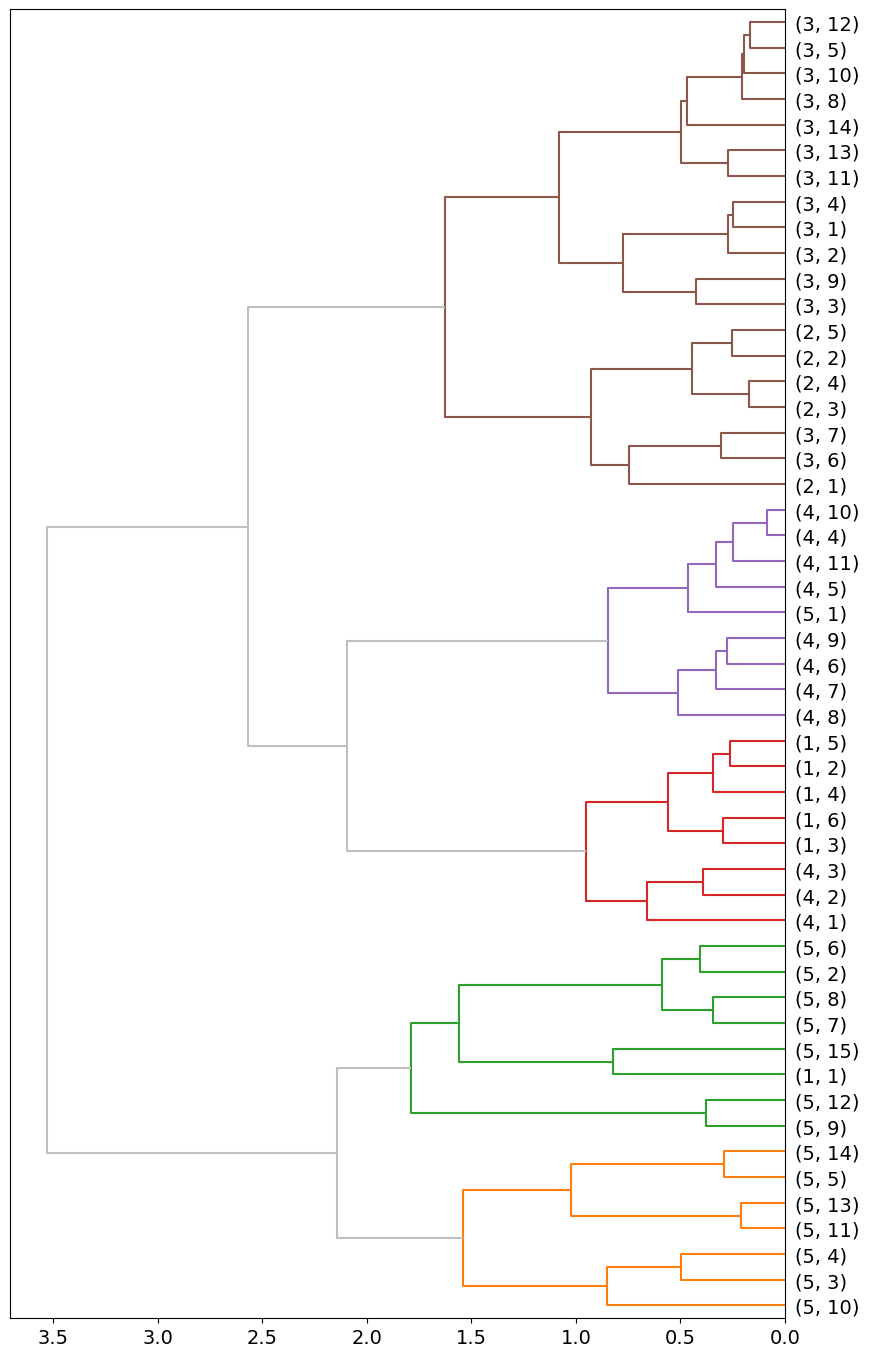

In [75]:
fig1.plot()

In [40]:
from sklearn.cluster import AgglomerativeClustering

In [84]:
n_clusters = 5

In [85]:
cluster = AgglomerativeClustering(n_clusters=n_clusters, 
    metric=metric, linkage=linkage)
DOC['label'] = (cluster.fit_predict(M)  + 1).astype(str)

In [86]:
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p label  
parte capit                  
1     1      0.008013     1  
      2      0.010906     1  
      3      0.020293     1  
      4      0.007284     1  
      5      0.014557     1

In [87]:
LABEL = DOC.label.value_counts().to_frame('n')

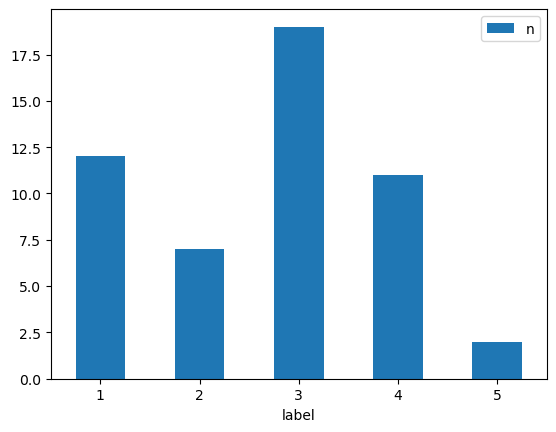

In [88]:
LABEL.sort_index().plot.bar(rot=0);

In [89]:
LABEL['color'] = pd.Series({
    '1': 'lightgray',
    '2': 'pink',
    '3': 'lightblue',
    '4': 'lightgreen',
    '5': 'lightyellow',
    '6': 'orange',
    '': 'white'
})

In [90]:
LABEL

,n,color
label,,
3,19,lightblue
1,12,lightgray
4,11,lightgreen
2,7,pink
5,2,lightyellow


In [91]:
DOC.label.unstack(fill_value='').style.map(lambda x: 'background:' + LABEL.loc[x, 'color'] if x != '' else 'background:white')

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
parte,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,,,,,,,,,
2,3,3,3,3,3,,,,,,,,,,
3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,
4,1,4,4,4,4,4,4,4,4,4,4,,,,
5,4,1,2,2,2,1,1,1,5,2,2,5,2,2,1


# Gloss LABEL

In [49]:
LABEL_TFIDF = M.join(DOC.label).groupby('label').mean()

In [50]:
LABEL['top_words'] = LABEL_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(20).index.to_list()), axis=1)

In [51]:
for row in LABEL.iterrows():
    print(row[0], row[1]['top_words'])

3 ri, k'ut, ta, k'u, jun, xa, junajpu, wi, xcha, kame, xib'alb'a, wuqub, chik, are, pa, k'ajolab, la, k'ate, xecha, xb'alanke
1 ta, ri, xa, k'ut, wi, puch, kaj, chik, winaq, k'iche, rumal, pa, ulew, are, ronojel, ajaw, q'ukumatz, pu, ajawab, k'u
4 ta, ri, b'alam, amaq, k'ut, wi, tojil, xa, k'u, kitze, are, q'ij, majukutaj, jakawitz, aq'ab, chik, chiri, awilix, xecha, ub'i
2 ajaw, unim, q'amja, ja, ajpop, ajawab, nim, lolmet, are, jun, b'elejeb, nija'ib'ab, wa, chokoj, winaq, chinamit, chuwach, ajtzik, kawiqib, q'alel
5 le, ajawarem, ajawab, k'otuja, b'alam, ajaw, uxe, b'elejeb, k'ute, chik, q'alel, kej, wa'e, kitze, k'ut, are, ukaj, chuwach, winaq, nab'e


# Inspect

In [52]:
def show_chap(parte, capit):
    print(DOC.loc[(parte,capit)].doc_str)

In [53]:
# show_chap(1,6)

In [54]:
show_chap(2,1)

ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW, MAJA B'I Q'IJ Jun k'ut kunimarisaj rib' Wuqub' Kaq'ix, ub'i'. K'o nab'e kaj, ulew, xa kamoymot uwach q'ij, ik'. Kacha' k'u ri': Xawi xere usaqetal winaq ri xb'utik, keje ri nawal winaq uk'oje'ik; -In nim kik'oje chik chuwi winaq tzaq, winaq b'it: in qu'ij, in pu usaq, in nay pu rik'il; ta chuxoq! Nim nusaqil, in b'inib'al, in pu chakab'al rumal winaq! Rumal puwaq ub'aq nuwach xa katiltotik chi yamanik, raxa k'uwal; nay pu we rax kawakoj chi ab'aj keje ri uwa kaj. Are k'u ri nutza'm saq julujuj chi naj k'eje ri ik'. Puwaq k'ut nuq'alib'al: k'a saq pak'e uwach ulew ta kinel uloq chuwach nuq'alib'al. K'eje k'ut in q'ij wi, in pu ik' rumal saqil al, saqil k'ajol. Ta chuxoq! Rumal chi naj kopon wi nuwach! Cha' ri Wuqub' Kak'ix. Ma k'u qitzij are ta q'ij ri Wuqub' Kak'ix. Xere kunimarisaj rib', ri uxik', upuwaq. Xere k'ut tokol wi uwach ri chi kub'e wi; mana ronojel ta uxe' kaj kopon wi uwach. Maja k'ut k'i kiloq uwach q'ij, ik', ch'umil, maja'oq ka

# Save

In [55]:
DOC.to_csv("colop-CHAP.csv", index=True)

In [56]:
for df in [(TFIDF, 'TFIDF'), (DOC, 'DOC'), (DTM, 'DTM'), (VOCAB, 'VOCAB'), (LABEL, 'LABEL')]:
    df[0].to_csv(f"colop-{df[1]}.csv", index=True)